# Marker Document Parser Testing

**WeatherSpeak PH** — Gemma 4 Hackathon

## About Marker

[Marker](https://github.com/datalab-to/marker) is a document conversion toolkit that:
- Converts PDFs, images, DOCX, PPTX → clean **Markdown / JSON / HTML**
- Handles **text, tables, and figures/charts** — not just text
- Built on top of Surya OCR with full layout analysis
- Extracts charts and diagrams as **separate image files**
- 20k+ stars, actively maintained by the Datalab team

### Why Marker Instead of EasyOCR or PaddleOCR?

PAGASA bulletins contain **both text and a storm track chart**. Traditional OCR tools (EasyOCR, PaddleOCR, Tesseract) are text-only — they ignore charts entirely.

Marker is the best **traditional/pipeline-based** tool for mixed-content documents:
- Extracts all text with structure preserved
- Detects and saves the storm track chart as a separate image
- Outputs clean Markdown (great for downstream LLM processing)

### Position in the Comparison

| Notebook | Tool | Handles Charts? | Output Format |
|---|---|---|---|
| 02 | Surya | Text/layout only | Plain text |
| 03 | **Marker** | ✅ Extracts as images | Markdown |
| 04 | Gemma 4 Vision | ✅ Understands semantically | Text / JSON |

## 1. Install Marker

In [1]:
# ! pip install torch torchvision
! pip install marker-pdf

  Using cached marker_pdf-1.10.2-py3-none-any.whl.metadata (30 kB)
  Using cached anthropic-0.46.0-py3-none-any.whl.metadata (23 kB)
  Using cached ftfy-6.3.1-py3-none-any.whl.metadata (7.3 kB)
  Using cached google_genai-1.72.0-py3-none-any.whl.metadata (52 kB)
  Using cached markdown2-2.5.5-py3-none-any.whl.metadata (2.1 kB)
  Using cached markdownify-1.2.2-py3-none-any.whl.metadata (9.9 kB)
  Using cached openai-1.109.1-py3-none-any.whl.metadata (29 kB)
  Using cached pdftext-0.6.3-py3-none-any.whl.metadata (8.5 kB)
  Using cached regex-2024.11.6-cp312-cp312-macosx_11_0_arm64.whl.metadata (40 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached pyasn1_modules-0.4.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached pycparser-3.0-py3-none-any.whl.metadata (8.2 kB)

In [2]:
! pip show marker-pdf

Name: marker-pdf
Version: 1.10.2
Summary: Convert documents to markdown with high speed and accuracy.
Home-page: 
Author: Vik Paruchuri
Author-email: github@vikas.sh
License: GPL-3.0-or-later
Location: /Users/josereyes/Dev/gemma4-hackathon/.venv/lib/python3.12/site-packages
Requires: anthropic, click, filetype, ftfy, google-genai, markdown2, markdownify, openai, pdftext, Pillow, pre-commit, pydantic, pydantic-settings, python-dotenv, rapidfuzz, regex, scikit-learn, surya-ocr, torch, tqdm, transformers
Required-by: 


In [3]:
import os
import json
from pathlib import Path
from PIL import Image
import time

# Marker v1.x API — PdfConverter handles both PDFs and images
from marker.converters.pdf import PdfConverter
from marker.models import create_model_dict
from marker.output import text_from_rendered
from marker.config.parser import ConfigParser

print("✓ Marker imported successfully")

/Users/josereyes/Dev/gemma4-hackathon/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Marker imported successfully


## 2. Load Sample Data

Load the same sample images used for Surya OCR.

In [4]:
# Load metadata
data_dir = Path("../data")
metadata_path = data_dir / "sample_metadata.json"

with open(metadata_path, 'r') as f:
    metadata = json.load(f)

samples = metadata['samples']
print(f"Loaded {len(samples)} sample images")

# Create output directories
output_dir = data_dir / "marker_results"
output_dir.mkdir(exist_ok=True)

figures_dir = output_dir / "figures"
figures_dir.mkdir(exist_ok=True)

Loaded 10 sample images


## 3. Initialize Marker Models

Marker loads several models for layout detection, OCR, and figure extraction.
Models are cached after the first download.

In [5]:
%%time
print("Loading Marker models (downloads on first run, cached thereafter)...")

config = {
    "output_format": "markdown",
    "langs": ["English"],
    "disable_image_extraction": False,  # keep chart extraction enabled
}
config_parser = ConfigParser(config)

# Load all models once and reuse across all images
artifact_dict = create_model_dict()

# Build converter
converter = PdfConverter(
    artifact_dict=artifact_dict,
    config=config_parser.generate_config_dict(),
    processor_list=config_parser.get_processors(),
    renderer=config_parser.get_renderer(),
)

print("✓ Marker models loaded")

Loading Marker models (downloads on first run, cached thereafter)...




















2026-04-11 23:21:21,571 [WARNING] surya: `TableRecEncoderDecoderModel` is not compatible with mps backend. Defaulting to cpu instead




































































































































































✓ Marker models loaded
CPU times: user 4.37 s, sys: 7.86 s, total: 12.2 s
Wall time: 2min 54s


## 4. Run Marker on Sample Images

Process each sample image. Marker will:
1. Extract all text in reading order
2. Preserve tables as Markdown tables
3. Detect and save figures (storm track charts) as separate images

In [6]:
results = []

for i, sample in enumerate(samples, 1):
    print(f"\n{'='*60}")
    print(f"Processing {i}/{len(samples)}: {sample['filename']}")
    print(f"{'='*60}")

    try:
        start_time = time.time()
        rendered = converter(sample['image_path'])
        processing_time = time.time() - start_time

        # text_from_rendered returns (markdown_str, ext_str, images_dict)
        markdown_text, _, extracted_images = text_from_rendered(rendered)

        # Save any extracted figures (e.g. storm track chart)
        stem = Path(sample['filename']).stem
        saved_figures = []
        for fig_name, fig_image in (extracted_images or {}).items():
            fig_path = figures_dir / f"{stem}_{fig_name}.png"
            fig_image.save(str(fig_path))
            saved_figures.append(str(fig_path))

        result = {
            'filename': sample['filename'],
            'storm': sample['storm'],
            'processing_time': processing_time,
            'num_lines': len(markdown_text.splitlines()),
            'num_figures': len(saved_figures),
            'figure_paths': saved_figures,
            'full_text': markdown_text,
            'success': True,
        }
        results.append(result)

        print(f"\n📊 Results:")
        print(f"  Processing time: {processing_time:.2f}s")
        print(f"  Lines extracted: {result['num_lines']}")
        print(f"  Figures extracted: {len(saved_figures)}")
        print(f"  Characters extracted: {len(markdown_text)}")
        print(f"\n📄 Extracted markdown (first 500 characters):")
        print("-" * 60)
        print(markdown_text[:500])
        print("-" * 60)

    except Exception as e:
        print(f"✗ Error processing {sample['filename']}: {e}")
        results.append({
            'filename': sample['filename'],
            'storm': sample['storm'],
            'processing_time': 0,
            'num_lines': 0,
            'num_figures': 0,
            'figure_paths': [],
            'full_text': '',
            'error': str(e),
            'success': False,
        })


Processing 1/10: PAGASA_20-19W_Pepito_SWB#01.pdf


Recognizing Layout:   0%|          | 0/1 [00:00<?, ?it/s]/Users/josereyes/Dev/gemma4-hackathon/.venv/lib/python3.12/site-packages/surya/common/surya/encoder/__init__.py:491: UserWarning: MPS: nonzero op is not natively supported for the provided input on MacOS14Falling back on CPU. This may have performance implications.See github.com/pytorch/pytorch/issues/122916 for further info (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/mps/operations/Indexing.mm:378.)
  attention_mask[valid_2d] = 0
Recognizing Text: 100%|██████████| 5/5 [00:35<00:00,  7.07s/it]



📊 Results:
  Processing time: 367.02s
  Lines extracted: 48
  Figures extracted: 3
  Characters extracted: 6164

📄 Extracted markdown (first 500 characters):
------------------------------------------------------------
![](_page_0_Figure_1.jpeg)

# **SEVERE WEATHER BULLETIN #1**

FOR: TROPICAL DEPRESSION "PEPITO"
TROPICAL CYCLONE: ALERT

### ISSUED AT 5:00 AM, 19 October 2020

(Valid for broadcast until the next bulletin to be issued at 11 AM today)

#### THE LOW PRESSURE AREA EAST OF CATANDUANES HAS DEVELOPED INTO TROPICAL DEPRESSION "PEPITO"

#### Track and intensity outlook:

- Track: "PEPITO" will move west northwestward or northwestward today, then turn more westward tomorrow towards the Northern Luzon-Ce
------------------------------------------------------------

Processing 2/10: PAGASA_20-19W_Pepito_SWB#02.pdf


Recognizing Text: 100%|██████████| 9/9 [00:49<00:00,  5.50s/it]



📊 Results:
  Processing time: 143.47s
  Lines extracted: 44
  Figures extracted: 2
  Characters extracted: 6211

📄 Extracted markdown (first 500 characters):
------------------------------------------------------------
![](_page_0_Figure_1.jpeg)

# **SEVERE WEATHER BULLETIN #2**

FOR: TROPICAL DEPRESSION "PEPITO"
TROPICAL CYCLONE: WARNING

## **ISSUED AT 11:00 AM, 19 October 2020**

(Valid for broadcast until the next bulletin to be issued at 5 PM today)

## TROPICAL DEPRESSION "PEPITO" ACCELERATES WESTWARD WHILE MAINTAINING ITS STRENGTH.

Track and intensity outlook:

- Track: "PEPITO" will move west northwestward or northwestward today, then turn westward tomorrow towards the Northern Luzon-Central Luzon are
------------------------------------------------------------

Processing 3/10: PAGASA_22-TC02_Basyang_TCA#01.pdf


...


📊 Results:
  Processing time: 56.22s
  Lines extracted: 55
  Figures extracted: 2
  Characters extracted: 3758

📄 Extracted markdown (first 500 characters):
------------------------------------------------------------
![](_page_0_Picture_1.jpeg)

# Republic of the Philippines DEPARTMENT OF SCIENCE AND TECHNOLOGY Philippine Atmospheric, Geophysical and Astronomical Services Administration (PAGASA) Weather Division

# TROPICAL CYCLONE ADVISORY NR. 3 Tropical Storm DANAS (Formerly "BISING")

Issued at 11:00 AM, 05 July 2025

Valid for broadcast until the next bulletin at 11:00 PM today.

### "DANAS" IS SLOWLY TURNING EAST NORTHEASTWARD OVER THE SEA WEST OF EXTREME NORTHERN LUZON

Location of Center (10:00 AM)

T
------------------------------------------------------------

Processing 9/10: PAGASA_26-TC02_Basyang_TCB#01.pdf


Recognizing Text: 100%|██████████| 66/66 [00:18<00:00,  3.62it/s]



📊 Results:
  Processing time: 53.34s
  Lines extracted: 57
  Figures extracted: 3
  Characters extracted: 3439

📄 Extracted markdown (first 500 characters):
------------------------------------------------------------
![](_page_0_Picture_1.jpeg)

# Republic of the Philippines DEPARTMENT OF SCIENCE AND TECHNOLOGY Philippine Atmospheric, Geophysical and Astronomical Services Administration (PAGASA)

Management System ISO 9001:2015

TÜVRheinland

![](_page_0_Picture_4.jpeg)

## TROPICAL CYCLONE BULLETIN NR. 1 Tropical Depression BASYANG

Weather Division

Issued at 11:00 PM, 03 February 2026 Valid for broadcast until the next bulletin at 5:00 AM tomorrow.

### THE TROPICAL DEPRESSION HAS ENTERED THE PHILIPPINE A
------------------------------------------------------------

Processing 10/10: PAGASA_26-TC02_Basyang_TCB#02.pdf


Recognizing Text: 100%|██████████| 67/67 [00:17<00:00,  3.89it/s]


📊 Results:
  Processing time: 44.98s
  Lines extracted: 51
  Figures extracted: 2
  Characters extracted: 3150

📄 Extracted markdown (first 500 characters):
------------------------------------------------------------
![](_page_0_Picture_1.jpeg)

## Republic of the Philippines DEPARTMENT OF SCIENCE AND TECHNOLOGY Philippine Atmospheric, Geophysical and Astronomical Services Administration (PAGASA) Weather Division

# TROPICAL CYCLONE BULLETIN NR. 2 **Tropical Depression BASYANG**

Issued at 5:00 AM, 04 February 2026

Valid for broadcast until the next bulletin at 11:00 AM today.

#### BASYANG ACCELERATES WEST SOUTHWESTWARD WHILE MAINTAINING ITS STRENGTH.

Location of Center (4:00 AM)

The center of Tropical D
------------------------------------------------------------


## 5. Save Results

In [7]:
# Save results to JSON
results_path = output_dir / "marker_results.json"
with open(results_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(f"✓ Results saved to: {results_path}")

# Save individual markdown files
for result in results:
    if result.get('success', False):
        md_path = output_dir / f"{Path(result['filename']).stem}.md"
        with open(md_path, 'w', encoding='utf-8') as f:
            f.write(result['full_text'])

print(f"✓ Markdown files saved to: {output_dir}")
print(f"✓ Extracted figures saved to: {figures_dir}")

✓ Results saved to: ../data/marker_results/marker_results.json
✓ Markdown files saved to: ../data/marker_results
✓ Extracted figures saved to: ../data/marker_results/figures


## 6. Performance Summary

In [8]:
import statistics

successful = [r for r in results if r.get('success', False)]
processing_times = [r['processing_time'] for r in successful]
line_counts = [r['num_lines'] for r in successful]
figure_counts = [r['num_figures'] for r in successful]

print("\n" + "="*60)
print("MARKER PERFORMANCE SUMMARY")
print("="*60)
print(f"\n📊 Processing Time:")
print(f"  Average: {statistics.mean(processing_times):.2f}s")
print(f"  Min: {min(processing_times):.2f}s")
print(f"  Max: {max(processing_times):.2f}s")
print(f"\n📄 Content:")
print(f"  Successful: {len(successful)}/{len(results)}")
print(f"  Average lines per page: {statistics.mean(line_counts):.0f}")
print(f"  Total figures extracted: {sum(figure_counts)}")
print(f"\n✓ All results saved to: {output_dir.absolute()}")


MARKER PERFORMANCE SUMMARY

📊 Processing Time:
  Average: 91.54s
  Min: 44.98s
  Max: 367.02s

📄 Content:
  Successful: 10/10
  Average lines per page: 52
  Total figures extracted: 25

✓ All results saved to: /Users/josereyes/Dev/gemma4-hackathon/notebooks/../data/marker_results


## 7. Visual Inspection

Display the original image alongside its extracted markdown and any detected figures.

Sample: PAGASA_20-19W_Pepito_SWB#01.pdf
Storm: pagasa-20-19W
Figures extracted: 3


🖼️  ORIGINAL IMAGE:


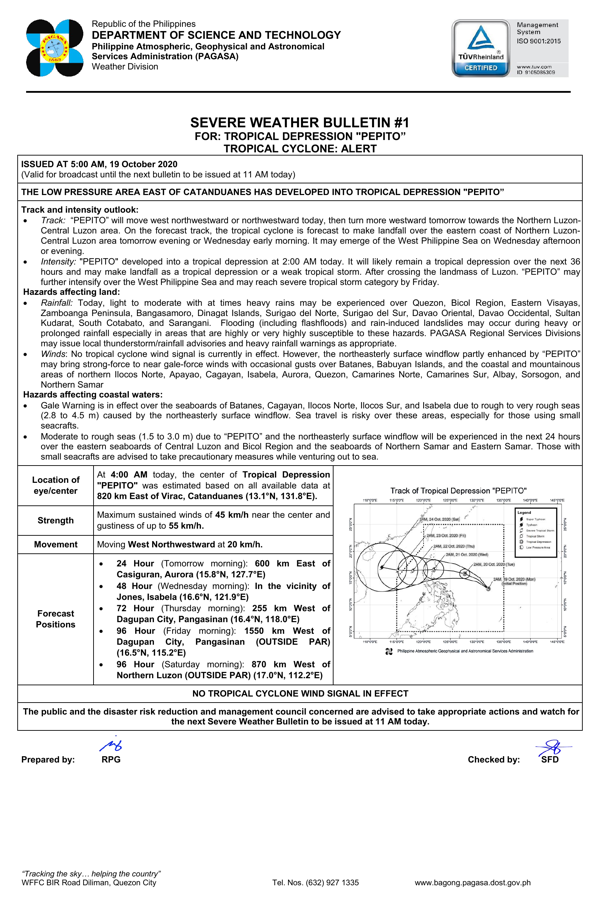


🗺️  EXTRACTED FIGURES (3):
  ../data/marker_results/figures/PAGASA_20-19W_Pepito_SWB#01__page_0_Figure_1.jpeg.png


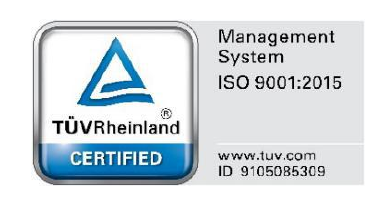

  ../data/marker_results/figures/PAGASA_20-19W_Pepito_SWB#01__page_0_Figure_17.jpeg.png


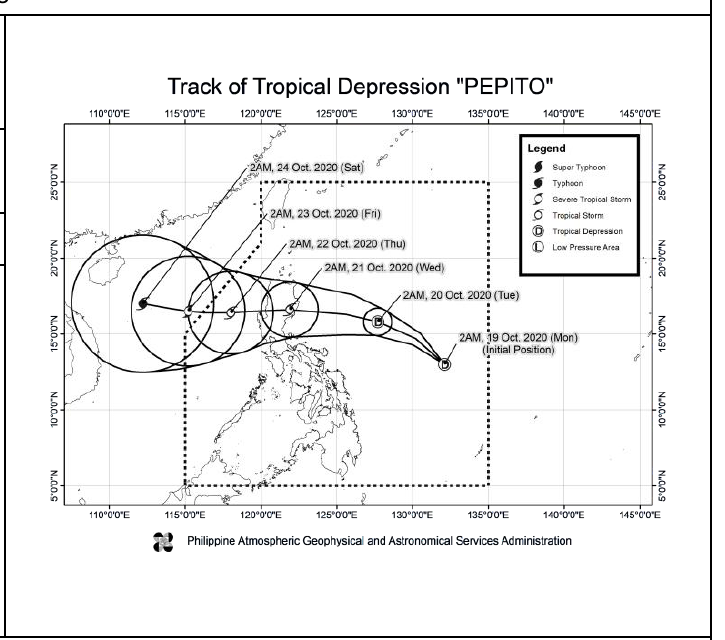

  ../data/marker_results/figures/PAGASA_20-19W_Pepito_SWB#01__page_0_Picture_23.jpeg.png


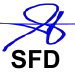


📄 EXTRACTED MARKDOWN:
![](_page_0_Figure_1.jpeg)

# **SEVERE WEATHER BULLETIN #1**

FOR: TROPICAL DEPRESSION "PEPITO"
TROPICAL CYCLONE: ALERT

### ISSUED AT 5:00 AM, 19 October 2020

(Valid for broadcast until the next bulletin to be issued at 11 AM today)

#### THE LOW PRESSURE AREA EAST OF CATANDUANES HAS DEVELOPED INTO TROPICAL DEPRESSION "PEPITO"

#### Track and intensity outlook:

- Track: "PEPITO" will move west northwestward or northwestward today, then turn more westward tomorrow towards the Northern Luzon-Central Luzon area. On the forecast track, the tropical cyclone is forecast to make landfall over the eastern coast of Northern Luzon-Central Luzon area tomorrow evening or Wednesday early morning. It may emerge of the West Philippine Sea on Wednesday afternoon or evening.
- Intensity: "PEPITO" developed into a tropical depression at 2:00 AM today. It will likely remain a tropical depression over the next 36 hours and may make landfall as a tropical depression or a weak trop

In [9]:
if successful:
    sample_result = successful[0]
    sample_info = next(s for s in samples if s['filename'] == sample_result['filename'])

    print(f"Sample: {sample_result['filename']}")
    print(f"Storm: {sample_result['storm']}")
    print(f"Figures extracted: {sample_result['num_figures']}")
    print("\n" + "="*60)

    # Show original image
    print("\n🖼️  ORIGINAL IMAGE:")
    img = Image.open(sample_info['image_path'])
    display(img.resize((600, int(600 * img.size[1] / img.size[0]))))

    # Show any extracted figures
    if sample_result['figure_paths']:
        print(f"\n🗺️  EXTRACTED FIGURES ({len(sample_result['figure_paths'])}):")
        for fig_path in sample_result['figure_paths']:
            print(f"  {fig_path}")
            fig_img = Image.open(fig_path)
            display(fig_img)
    else:
        print("\n⚠️  No figures extracted from this sample")

    # Show extracted markdown
    print("\n📄 EXTRACTED MARKDOWN:")
    print("="*60)
    print(sample_result['full_text'])
    print("="*60)

## 8. Preliminary Assessment

### ✅ Strengths vs Traditional OCR
- Handles **mixed content** — text and charts in one pass
- Outputs **structured Markdown** (preserves headers, tables, reading order)
- Storm track chart extracted as a separate image
- Clean output ready for downstream LLM processing
- `PdfConverter` handles both PDFs and images — same API, no conversion needed

### ⚠️ Limitations
- Chart extraction saves the image — it does **not understand** what the chart means
- Still needs a separate vision model to interpret storm tracks, intensity arrows, etc.
- Heavier than pure text OCR (Surya is faster for text-only tasks)

### ❓ Questions for Comparison
- Is text accuracy comparable to Surya?
- Does Markdown structure help downstream translation?
- Can Gemma 4 Vision do all of this — text + chart understanding — in one step?

### 📝 Next Steps
Proceed to **Notebook 04** to test Gemma 4 Vision — the key hypothesis is that a single multimodal model can replace this entire pipeline and *understand* the charts, not just extract them.